In [1]:
import sys
import subprocess
import importlib

_required = ["torch", "torchvision", "matplotlib", "numpy<2.0"]
_missing = []
for _mod in _required:
    try:
        importlib.import_module(_mod)
    except ImportError:
        _missing.append(_mod)

if _missing:
    print(f"Installing missing packages: {_missing}")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *_missing])
    except subprocess.CalledProcessError as e:
        print("Package installation failed:", e)
        raise

importlib.invalidate_caches()

# Perform the original imports
import torch.nn as nn

print("All imports succeeded.")

Installing missing packages: ['numpy<2.0']
All imports succeeded.


In [17]:
# Import required libraries
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from model import get_model
import utils

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: cpu


In [19]:
has_mps = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if has_mps
    else "cpu"
)
print("Using:", device)

Using: mps


In [46]:
# Load MNIST test dataset
transform = transforms.Compose([
    transforms.ToTensor(),
])

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Use a subset for faster testing (300 samples)
# For full evaluation, you can use the entire test set (10,000 samples)
test_subset = torch.utils.data.Subset(test_dataset, range(10000))
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=10000, shuffle=False)

# Get a batch of test data
x_test, y_test = next(iter(test_loader))

# Flatten images from (batch, 1, 28, 28) to (batch, 784)
x_test = x_test.view(x_test.size(0), -1).to(device)
y_test = y_test.to(device)

print(f"Test set size: {x_test.shape[0]}")
print(f"Image shape (flattened): {x_test.shape[1]}")
print(f"Data range: {x_test.min():.3f} to {x_test.max():.3f}")

Test set size: 10000
Image shape (flattened): 784
Data range: 0.000 to 1.000


In [47]:
# Load pre-trained model
model = get_model(pretrained_path="data/model.pth", device=device)

# Evaluate clean accuracy
clean_acc = utils.accuracy(model, x_test, y_test)
print(f"Clean accuracy (unperturbed): {clean_acc:.4f}")

#Evaluate adv accuracy
adv_acc = utils.evaluate_and_export(model, x_test, y_test, x_test)
print(f"Adv accuracy (unperturbed): ", adv_acc)

Clean accuracy (unperturbed): 0.9736
Adv accuracy (unperturbed):  {'clean_accuracy': 0.9736, 'adv_accuracy': 0.9736, 'avg_linf': 0.0, 'n_samples': 10000}


In [48]:
x_test.shape

torch.Size([10000, 784])

In [23]:
# simple speed check (tiny example)
import torch, time
device = "mps" if hasattr(torch.backends,"mps") and torch.backends.mps.is_available() else "cpu"
x = torch.randn(2048, 2048, device=device)
t0 = time.time(); y = x @ x; torch.cuda.synchronize() if device=="cuda" else None
print(device, "matmul ms:", (time.time()-t0)*1000)

mps matmul ms: 64.61620330810547


In [24]:
import torch
import torch.nn.functional as F
import utils
import os

# --- FGSM helper (works with flattened inputs) ---
def fgsm_attack(model, x, y, eps, loss_fn=None, device='cpu'):
    """
    Create FGSM adversarial examples for a *single* batch (x, y).
    x: (N, D) in [0,1], requires no grad on entry
    y: (N,)
    eps: epsilon for Linf ball (e.g., 0.1)
    """
    model.eval()
    x_adv = x.clone().detach().to(device)
    y = y.to(device)

    x_adv.requires_grad_(True)

    # Forward to get logits
    logits = model(x_adv)  # expect (N, C)
    if loss_fn is None:
        loss_fn = F.cross_entropy
    loss = loss_fn(logits, y)

    # Backward to get grad wrt input
    loss.backward()

    # FGSM: sign of gradient
    with torch.no_grad():
        grad_sign = x_adv.grad.sign()
        x_adv = x_adv + eps * grad_sign
        x_adv.clamp_(0.0, 1.0)

    return x_adv.detach()

# --- Run a sweep of epsilons and export metrics+example images ---
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2]  # adjust as you like
all_metrics = []

os.makedirs("attack_out", exist_ok=True)

for eps in epsilons:
    x_adv = fgsm_attack(model, x_test, y_test, eps=eps, device=device)

    # results/ files per epsilon
    tag = f"attack_out/mnist_fgsm_eps{str(eps).replace('.','p')}"
    metrics = utils.evaluate_and_export(model, x_test, y_test, x_adv, out_prefix=tag)
    metrics["epsilon"] = float(eps)
    all_metrics.append(metrics)
    print(f"eps={eps:.2f} -> clean_acc={metrics['clean_accuracy']:.4f}, "
          f"adv_acc={metrics['adv_accuracy']:.4f}, avg_linf={metrics['avg_linf']:.4f}")

# (Optional) quick look at the metrics list
all_metrics


eps=0.00 -> clean_acc=0.9690, adv_acc=0.9690, avg_linf=0.0000
eps=0.05 -> clean_acc=0.9690, adv_acc=0.6000, avg_linf=0.0500
eps=0.10 -> clean_acc=0.9690, adv_acc=0.2380, avg_linf=0.1000
eps=0.15 -> clean_acc=0.9690, adv_acc=0.1450, avg_linf=0.1500
eps=0.20 -> clean_acc=0.9690, adv_acc=0.1070, avg_linf=0.2000


[{'clean_accuracy': 0.969,
  'adv_accuracy': 0.969,
  'avg_linf': 0.0,
  'n_samples': 1000,
  'epsilon': 0.0},
 {'clean_accuracy': 0.969,
  'adv_accuracy': 0.6,
  'avg_linf': 0.050000015646219254,
  'n_samples': 1000,
  'epsilon': 0.05},
 {'clean_accuracy': 0.969,
  'adv_accuracy': 0.238,
  'avg_linf': 0.10000003129243851,
  'n_samples': 1000,
  'epsilon': 0.1},
 {'clean_accuracy': 0.969,
  'adv_accuracy': 0.145,
  'avg_linf': 0.15000003576278687,
  'n_samples': 1000,
  'epsilon': 0.15},
 {'clean_accuracy': 0.969,
  'adv_accuracy': 0.107,
  'avg_linf': 0.20000003278255463,
  'n_samples': 1000,
  'epsilon': 0.2}]

In [25]:
for d in range(10):
    idx = (y_test == d)
    print(d, (model.predict(x_adv[idx]) == y_test[idx]).float().mean().item())

0 0.2705882489681244
1 0.0
2 0.17241379618644714
3 0.037383176386356354
4 0.12727272510528564
5 0.14942528307437897
6 0.24137930572032928
7 0.0
8 0.13483145833015442
9 0.0


In [26]:
import torch
preds_adv = model.predict(x_adv)
for d in range(10):
    idx = (y_test == d)
    n = idx.sum().item()
    acc = (preds_adv[idx] == y_test[idx]).float().mean().item() if n>0 else float('nan')
    print(d, n, acc)


0 85 0.2705882489681244
1 126 0.0
2 116 0.17241379618644714
3 107 0.037383176386356354
4 110 0.12727272510528564
5 87 0.14942528307437897
6 87 0.24137930572032928
7 99 0.0
8 89 0.13483145833015442
9 94 0.0


In [27]:
import numpy as np
K = 10
cm = np.zeros((K,K), dtype=int)
pc = model.predict(x_test)  # clean
pa = model.predict(x_adv)   # adv
for t, p in zip(y_test.cpu().numpy(), pa.cpu().numpy()):
    cm[t, p] += 1
print(cm)


[[23  0  5  2  2 11 14  6 13  9]
 [ 0  0  9 15  6  3  1 24 59  9]
 [ 0  4 20 15  0 18  5  6 47  1]
 [ 3  0  2  4  0 25  5  7 61  0]
 [11  0  5  3 14 15  6  8 25 23]
 [ 1  0  1 18  1 13  3  4 42  4]
 [ 9  0  2  0  6 28 21  0 21  0]
 [20  0  1 17  2 14  2  0 38  5]
 [ 4  2 21 17  4 16  3  3 12  7]
 [ 1  2 13  3 25  4  9  8 29  0]]


In [29]:
import matplotlib as plt

In [31]:
from math import sqrt
def wilson(p, n, z=1.96):
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    margin = (z*sqrt(p*(1-p)/n + z*z/(4*n*n))) / denom
    return center - margin, center + margin

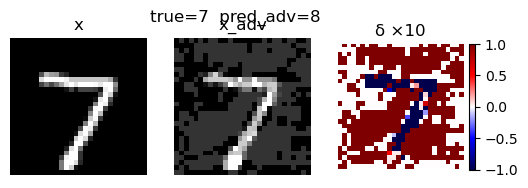

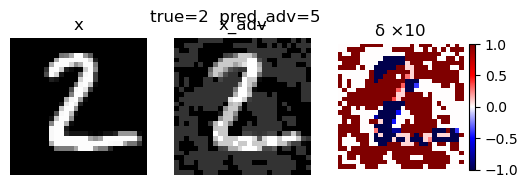

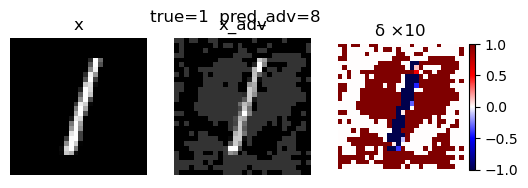

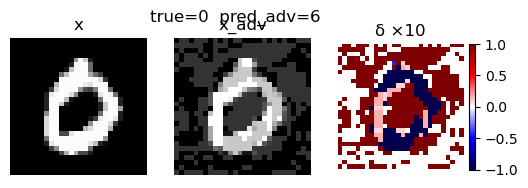

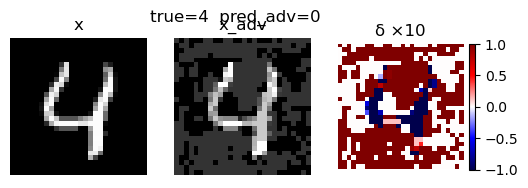

In [32]:
import matplotlib.pyplot as plt

def show_triplet(i):
    x0 = x_test[i].view(28,28).cpu()
    xa = x_adv[i].view(28,28).cpu()
    delta = (xa - x0)

    fig, axs = plt.subplots(1,3, figsize=(6,2))
    axs[0].imshow(x0, cmap='gray'); axs[0].set_title('x'); axs[0].axis('off')
    axs[1].imshow(xa, cmap='gray'); axs[1].set_title('x_adv'); axs[1].axis('off')
    im = axs[2].imshow((delta*10).clamp(-1,1), cmap='seismic'); axs[2].set_title('δ ×10'); axs[2].axis('off')
    plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)
    plt.suptitle(f"true={int(y_test[i])}  pred_adv={int(model.predict(x_adv[i:i+1])[0])}")
    plt.show()

# Example: show 3 failures (completely fooled classes like 1,7,9)
for i in range(5):
    if model.predict(x_adv[i:i+1])[0] != y_test[i]:
        show_triplet(i)

In [35]:
import time, torch, torch.nn as nn, torch.nn.functional as F, pandas as pd

def has_mps():
    return hasattr(torch.backends, "mps") and torch.backends.mps.is_available()

def sync(dev):
    if dev == "cuda" and torch.cuda.is_available():
        torch.cuda.synchronize()
    elif dev == "mps" and has_mps():
        import torch.mps; torch.mps.synchronize()

def time_it(label, device, run_fn, warmup=2, iters=8):
    for _ in range(warmup): run_fn()
    sync(device)
    t0 = time.perf_counter()
    for _ in range(iters): run_fn()
    sync(device)
    t1 = time.perf_counter()
    return {"test": label, "device": device, "iters": iters,
            "total_sec": t1 - t0, "avg_ms_per_iter": (t1 - t0)*1000/iters}

# --- Matmul 512x512 ---
def make_matmul(device):
    n = 512
    a = torch.randn(n, n, device=device)
    b = torch.randn(n, n, device=device)
    def run():
        c = a @ b
        _ = c[0,0]
    return run

# --- Tiny CNN forward ---
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8,16, 3, padding=1)
        self.fc = nn.Linear(16*16*16, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)        # 32x32 -> 16x16
        x = F.relu(self.conv2(x))
        x = F.adaptive_avg_pool2d(x, (16,16))
        x = x.view(x.size(0), -1)
        return self.fc(x)

def make_cnn_run(device):
    model = TinyCNN().to(device)
    x = torch.randn(8, 3, 32, 32, device=device)
    def run():
        with torch.no_grad():
            y = model(x); _ = y[0,0]
    return run

devices = ["cpu"] + (["mps"] if has_mps() else [])
rows = []
for dev in devices:
    rows.append(time_it("matmul_512x512", dev, make_matmul(dev), warmup=2, iters=6))
    rows.append(time_it("tinycnn_forward_8x3x32x32", dev, make_cnn_run(dev), warmup=2, iters=10))

print(pd.DataFrame(rows))


                        test device  iters  total_sec  avg_ms_per_iter
0             matmul_512x512    cpu      6   0.001229         0.204861
1  tinycnn_forward_8x3x32x32    cpu     10   0.005773         0.577292
2             matmul_512x512    mps      6   0.003952         0.658639
3  tinycnn_forward_8x3x32x32    mps     10   0.002938         0.293813


In [42]:
def ifgsm_untargeted(model, x, y, eps, alpha, steps, device="cpu"):
    model.eval()
    x_orig = x.detach().to(device)
    y = y.to(device)

    # (optional) random start inside the eps-box:
    x_adv = x_orig + torch.empty_like(x_orig).uniform_(-eps, eps)
    x_adv = (linf_proj(x_adv, x_orig, eps)).clamp_(0.0, 1.0).detach()

    for _ in range(steps):
        x_adv = x_adv.clone().detach().requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, y)
        loss.backward()

        with torch.no_grad():
            x_adv = x_adv + alpha * x_adv.grad.sign()   # untargeted: plus sign
            x_adv = x_adv.clamp_(0.0, 1.0)
            x_adv = linf_proj(x_adv, x_orig, eps)       # keep within eps of x
    return x_adv.detach()


In [38]:
def ifgsm_targeted(model, x, y_target, eps, alpha, steps, device="cpu"):
    model.eval()
    x_orig = x.detach().to(device)
    y_target = y_target.to(device)

    x_adv = x_orig + torch.empty_like(x_orig).uniform_(-eps, eps)
    x_adv = clamp01(linf_proj(x_adv, x_orig, eps)).detach()

    for _ in range(steps):
        x_adv = x_adv.clone().detach().requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, y_target)
        loss.backward()

        with torch.no_grad():
            x_adv = x_adv - alpha * x_adv.grad.sign()   # targeted: minus sign
            x_adv = clamp01(x_adv)
            x_adv = linf_proj(x_adv, x_orig, eps)
    return x_adv.detach()

In [43]:
# Example hyperparams (ε = 8/255, α = 2/255, 10 steps)
eps = 8/255.0
alpha = 2/255.0
steps = 10

x_adv_ifgsm = ifgsm_untargeted(model, x_test, y_test, eps, alpha, steps, device=device)
adv_acc = utils.accuracy(model, x_adv_ifgsm, y_test)
print("I-FGSM adv accuracy:", adv_acc)

# Targeted toward class '7'
y_tgt = torch.full_like(y_test, 7)
x_adv_tgt = ifgsm_targeted(model, x_test, y_tgt, eps, alpha, steps, device=device)


NameError: name 'linf_proj' is not defined

In [49]:
# ==== I-FGSM (untargeted) grid sweep over eps and alpha ====
import os, json, math
import torch
import torch.nn.functional as F
import pandas as pd
import utils  # uses your evaluate_and_export()

# --- Helpers ---
def _linf_project(x_adv, x_orig, eps):
    # keep total change within L_inf epsilon of the original
    return x_orig + (x_adv - x_orig).clamp(min=-eps, max=eps)

def ifgsm_untargeted(model, x, y, eps, alpha, steps, random_start=True,
                     clip_min=0.0, clip_max=1.0, device="cpu"):
    model.eval()
    x_orig = x.detach().to(device)
    y = y.to(device)

    if random_start:
        x_adv = x_orig + torch.empty_like(x_orig).uniform_(-eps, eps)
        x_adv = _linf_project(x_adv, x_orig, eps).clamp(clip_min, clip_max).detach()
    else:
        x_adv = x_orig.clone().detach()

    for _ in range(steps):
        x_adv = x_adv.clone().detach().requires_grad_(True)
        loss = F.cross_entropy(model(x_adv), y)
        loss.backward()
        with torch.no_grad():
            x_adv = x_adv + alpha * x_adv.grad.sign()         # untargeted = plus
            x_adv = _linf_project(x_adv, x_orig, eps)         # keep within ε
            x_adv = x_adv.clamp(clip_min, clip_max)           # valid pixels
    return x_adv.detach()

# --- Config ---
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)

# Use your existing: model, x_test (N,784 in [0,1]), y_test
# If not already on device:
model.to(device); x_test = x_test.to(device); y_test = y_test.to(device)

# Sweep lists (tweak as you like)
eps_list   = [2/255, 4/255, 8/255, 16/255, 32/255]   # total budget
alpha_list = [1/255, 2/255, 4/255, 8/255]            # per-step size
steps      = 10                                      # number of tiny pushes
random_start = True                                  # PGD-style

os.makedirs("attack_out", exist_ok=True)
rows = []

for eps in eps_list:
    for alpha in alpha_list:
        # (optional) skip silly combos where alpha >> eps (projection will handle it, but it’s wasteful)
        # if alpha > eps: continue

        x_adv = ifgsm_untargeted(model, x_test, y_test, eps, alpha, steps,
                                 random_start=random_start, device=device)

        tag = (
            f"attack_out/mnist_ifgsm_eps{str(round(eps,6)).replace('.','p')}"
            f"_a{str(round(alpha,6)).replace('.','p')}_s{steps}"
        )
        metrics = utils.evaluate_and_export(model, x_test, y_test, x_adv, out_prefix=tag)
        metrics.update({
            "epsilon": float(eps),
            "alpha": float(alpha),
            "steps": int(steps),
            "random_start": bool(random_start),
        })
        rows.append(metrics)
        print(f"eps={eps:.5f} alpha={alpha:.5f}  "
              f"clean={metrics['clean_accuracy']:.4f}  "
              f"adv={metrics['adv_accuracy']:.4f}  "
              f"avg_linf={metrics['avg_linf']:.5f}")

# Save a tidy summary table
df = pd.DataFrame(rows)
csv_path = "attack_out/ifgsm_grid_results.csv"
df.to_csv(csv_path, index=False)
print("Saved:", csv_path)

# (Optional) show the best/worst combos by adversarial accuracy
print("\nTop 5 strongest attacks (lowest adv_accuracy):")
display(df.sort_values("adv_accuracy").head(5))

print("\nTop 5 weakest attacks (highest adv_accuracy):")
display(df.sort_values("adv_accuracy", ascending=False).head(5))

Device: mps
eps=0.00784 alpha=0.00392  clean=0.9736  adv=0.9545  avg_linf=0.00784
eps=0.00784 alpha=0.00784  clean=0.9736  adv=0.9546  avg_linf=0.00784
eps=0.00784 alpha=0.01569  clean=0.9736  adv=0.9547  avg_linf=0.00784
eps=0.00784 alpha=0.03137  clean=0.9736  adv=0.9547  avg_linf=0.00784
eps=0.01569 alpha=0.00392  clean=0.9736  adv=0.9254  avg_linf=0.01569
eps=0.01569 alpha=0.00784  clean=0.9736  adv=0.9252  avg_linf=0.01569
eps=0.01569 alpha=0.01569  clean=0.9736  adv=0.9261  avg_linf=0.01569
eps=0.01569 alpha=0.03137  clean=0.9736  adv=0.9269  avg_linf=0.01569
eps=0.03137 alpha=0.00392  clean=0.9736  adv=0.8128  avg_linf=0.03137
eps=0.03137 alpha=0.00784  clean=0.9736  adv=0.8010  avg_linf=0.03137
eps=0.03137 alpha=0.01569  clean=0.9736  adv=0.8022  avg_linf=0.03137
eps=0.03137 alpha=0.03137  clean=0.9736  adv=0.8092  avg_linf=0.03137
eps=0.06275 alpha=0.00392  clean=0.9736  adv=0.6112  avg_linf=0.06275
eps=0.06275 alpha=0.00784  clean=0.9736  adv=0.3589  avg_linf=0.06275
eps=0.06

,clean_accuracy,adv_accuracy,avg_linf,n_samples,epsilon,alpha,steps,random_start
19,0.9736,0.0364,0.125490,10000,0.125490,0.031373,10,True
18,0.9736,0.0531,0.125490,10000,0.125490,0.015686,10,True
17,0.9736,0.1593,0.125490,10000,0.125490,0.007843,10,True
14,0.9736,0.3231,0.062745,10000,0.062745,0.015686,10,True
15,0.9736,0.3288,0.062745,10000,0.062745,0.031373,10,True



Top 5 weakest attacks (highest adv_accuracy):


,clean_accuracy,adv_accuracy,avg_linf,n_samples,epsilon,alpha,steps,random_start
2,0.9736,0.9547,0.007843,10000,0.007843,0.015686,10,True
3,0.9736,0.9547,0.007843,10000,0.007843,0.031373,10,True
1,0.9736,0.9546,0.007843,10000,0.007843,0.007843,10,True
0,0.9736,0.9545,0.007843,10000,0.007843,0.003922,10,True
7,0.9736,0.9269,0.015686,10000,0.015686,0.031373,10,True


In [50]:
# ==== Carlini & Wagner L2 attack (targeted + untargeted) ====
import torch
import torch.nn.functional as F
import math

# Choose device (CUDA / MPS / CPU)
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)
print("CW device:", device)

def _to_logits(model, x):
    return model(x)

def _tanh_to_img(w, clip_min=0.0, clip_max=1.0):
    # map unconstrained w -> [clip_min, clip_max] via tanh
    x = 0.5*(torch.tanh(w) + 1.0)
    if clip_min != 0.0 or clip_max != 1.0:
        x = x*(clip_max-clip_min) + clip_min
    return x

def _img_to_tanh(x, clip_min=0.0, clip_max=1.0):
    # inverse mapping (avoid ±1 exactly to keep atanh stable)
    x = (x - clip_min)/(clip_max - clip_min)
    x = x.clamp(1e-6, 1-1e-6)
    return torch.atanh(2.0*x - 1.0)

def cw_loss_targeted(logits, y_target, kappa=0.0):
    # f(x) = max(max_{i≠t} z_i - z_t, -kappa)
    one_hot = F.one_hot(y_target, num_classes=logits.size(1)).bool()
    z_t = logits[one_hot]                          # (N,)
    z_not_t, _ = (logits.masked_fill(one_hot, -1e9)).max(dim=1)
    return torch.clamp(z_not_t - z_t, min=-kappa).mean()

def cw_loss_untargeted(logits, y_true, kappa=0.0):
    # f(x) = max(z_y - max_{i≠y} z_i, -kappa)
    one_hot = F.one_hot(y_true, num_classes=logits.size(1)).bool()
    z_y = logits[one_hot]                           # (N,)
    z_not_y, _ = (logits.masked_fill(one_hot, -1e9)).max(dim=1)
    return torch.clamp(z_y - z_not_y, min=-kappa).mean()

@torch.no_grad()
def _success_targeted(model, x_adv, y_target):
    preds = _to_logits(model, x_adv).argmax(1)
    return (preds == y_target).float().mean().item()

@torch.no_grad()
def _success_untargeted(model, x_adv, y_true):
    preds = _to_logits(model, x_adv).argmax(1)
    return (preds != y_true).float().mean().item()

def cw_l2_targeted(model, x, y_target, c=1e-2, kappa=0.0, steps=1000, lr=1e-2,
                   clip_min=0.0, clip_max=1.0, device=device, verbose=False):
    """
    Targeted CW-L2: minimize ||x_adv - x||_2^2 + c * f_targeted(x_adv)
    Returns x_adv.
    """
    model.eval()
    x = x.to(device)
    y_target = y_target.to(device)

    # Reparameterize: w is free, x_adv = tanh(w) mapped to [0,1]
    w = _img_to_tanh(x, clip_min, clip_max).detach()
    w = w.clone().requires_grad_(True)

    opt = torch.optim.Adam([w], lr=lr)

    for i in range(steps):
        x_adv = _tanh_to_img(w, clip_min, clip_max)
        logits = _to_logits(model, x_adv)

        l2 = F.mse_loss(x_adv, x, reduction='sum') / x.size(0)  # mean per-sample L2^2
        f = cw_loss_targeted(logits, y_target, kappa=kappa)

        loss = l2 + c * f
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if verbose and (i % 100 == 0 or i == steps-1):
            sr = _success_targeted(model, x_adv, y_target)
            print(f"[{i:04d}] loss={loss.item():.4f}  L2^2={l2.item():.4f}  f={f.item():.4f}  succ={sr:.3f}")

    return _tanh_to_img(w, clip_min, clip_max).detach()

def cw_l2_untargeted(model, x, y_true, c=1e-2, kappa=0.0, steps=1000, lr=1e-2,
                     clip_min=0.0, clip_max=1.0, device=device, verbose=False):
    """
    Untargeted CW-L2: minimize ||x_adv - x||_2^2 + c * f_untargeted(x_adv)
    Returns x_adv.
    """
    model.eval()
    x = x.to(device)
    y_true = y_true.to(device)

    w = _img_to_tanh(x, clip_min, clip_max).detach()
    w = w.clone().requires_grad_(True)

    opt = torch.optim.Adam([w], lr=lr)

    for i in range(steps):
        x_adv = _tanh_to_img(w, clip_min, clip_max)
        logits = _to_logits(model, x_adv)

        l2 = F.mse_loss(x_adv, x, reduction='sum') / x.size(0)  # mean per-sample L2^2
        f = cw_loss_untargeted(logits, y_true, kappa=kappa)

        loss = l2 + c * f
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if verbose and (i % 100 == 0 or i == steps-1):
            sr = _success_untargeted(model, x_adv, y_true)
            print(f"[{i:04d}] loss={loss.item():.4f}  L2^2={l2.item():.4f}  f={f.item():.4f}  succ={sr:.3f}")

    return _tanh_to_img(w, clip_min, clip_max).detach()


CW device: mps


In [55]:
import torch
import torch.nn.functional as F
import numpy as np
import utils

# --- stricter targeted success: must become target AND not already target AND misclassify true label
@torch.no_grad()
def targeted_success_rate(model, x_clea¸n, y_true, x_adv, y_target):
    pred_clean = model(x_clean).argmax(1)
    pred_adv   = model(x_adv).argmax(1)
    ok = (pred_adv == y_target) & (pred_clean != y_target) & (pred_adv != y_true)
    return ok.float().mean().item()

def run_cw_targeted_c_search(model, x, y_true, target_class=7,
                             c_list=(1e-3, 1e-2, 1e-1, 1, 10),
                             kappa=0.0, steps=800, lr=1e-2, device="cpu"):
    y_tgt = torch.full_like(y_true, target_class)
    best = Nonç
    rows = []
    for c in c_list:
        x_adv = cw_l2_targeted(model, x, y_tgt, c=c, kappa=kappa, steps=steps, lr=lr, device=device, verbose=True)
        # metrics
        strict_sr = targeted_success_rate(model, x, y_true, x_adv, y_tgt)
        metrics = utils.evaluate_and_export(model, x, y_true, x_adv,
                                            out_prefix=f"attack_out/cw_tgt7_c{str(c).replace('.','p')}_k{kappa}")
        row = {"c": c, "kappa": kappa, "steps": steps, "lr": lr,
               "strict_target_success": strict_sr,
               **metrics}
        rows.append(row)
        # keep the best (highest strict success; tie-breaker = lower L2)
        if best is None or strict_sr > best["strict_target_success"] or \
           (np.isclose(strict_sr, best["strict_target_success"]) and row["avg_linf"] < best["avg_linf"]):
            best = row
        print(f"[c={c:.4g}] strict_tgt_SR={strict_sr:.3f}  adv_acc={metrics['adv_accuracy']:.3f}  avg_linf={metrics['avg_linf']:.5f}")
    print("\nBEST:", best)
    return rows, best

# ---- Run on a small batch for speed (you can scale up later)
idx = torch.arange(0, 10000)
x_batch = x_test[idx]
y_batch = y_test[idx]

rows, best = run_cw_targeted_c_search(
    model, x_batch, y_batch,
    target_class=7,
    c_list=(1e-3, 1e-2, 1e-1, 5e-1, 1, 2, 5, 10),  # ramp c up
    kappa=0.0,                                      # try 0 first; then 5 for stronger targets
    steps=800, lr=1e-2,
    device=device
)


[0000] loss=0.0202  L2^2=0.0000  f=20.2311  succ=0.102
[0100] loss=0.0202  L2^2=0.0000  f=20.2010  succ=0.102
[0200] loss=0.0202  L2^2=0.0000  f=20.2003  succ=0.102
[0300] loss=0.0202  L2^2=0.0000  f=20.2002  succ=0.103
[0400] loss=0.0202  L2^2=0.0000  f=20.2002  succ=0.102
[0500] loss=0.0202  L2^2=0.0000  f=20.2002  succ=0.102
[0600] loss=0.0202  L2^2=0.0000  f=20.2002  succ=0.103
[0700] loss=0.0202  L2^2=0.0000  f=20.2002  succ=0.102
[0799] loss=0.0202  L2^2=0.0000  f=20.2002  succ=0.103
[c=0.001] strict_tgt_SR=0.000  adv_acc=0.974  avg_linf=0.00091
[0000] loss=0.2023  L2^2=0.0000  f=20.2311  succ=0.102
[0100] loss=0.2008  L2^2=0.0015  f=19.9321  succ=0.103
[0200] loss=0.2008  L2^2=0.0015  f=19.9273  succ=0.103
[0300] loss=0.2008  L2^2=0.0015  f=19.9265  succ=0.103
[0400] loss=0.2008  L2^2=0.0015  f=19.9260  succ=0.103
[0500] loss=0.2008  L2^2=0.0015  f=19.9257  succ=0.103
[0600] loss=0.2008  L2^2=0.0015  f=19.9255  succ=0.103
[0700] loss=0.2008  L2^2=0.0015  f=19.9254  succ=0.103
[0

KeyboardInterrupt: 

mean L2: 0.0322248712182045  median L2: 0.0342111811041832  max L2: 0.06136229634284973


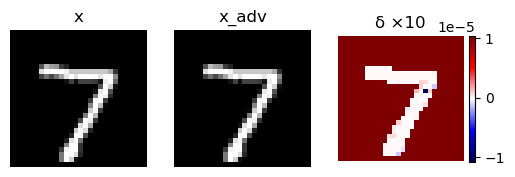

In [53]:
import torch
import matplotlib.pyplot as plt

# Assume x_batch, x_adv_cw_t from your run (same shapes, [0,1])
delta = (x_adv_cw_t - x_batch).detach()
l2_per = delta.norm(p=2, dim=1)  # L2 per image
print("mean L2:", l2_per.mean().item(), " median L2:", l2_per.median().item(),
      " max L2:", l2_per.max().item())

# visual triplet
i = 0
x0 = x_batch[i].view(28,28).cpu()
xa = x_adv_cw_t[i].view(28,28).cpu()
d  = (xa - x0)
fig, axs = plt.subplots(1,3, figsize=(6,2))
axs[0].imshow(x0, cmap='gray'); axs[0].set_title('x');     axs[0].axis('off')
axs[1].imshow(xa, cmap='gray'); axs[1].set_title('x_adv'); axs[1].axis('off')
im = axs[2].imshow((d*10).clamp(-1,1), cmap='seismic'); axs[2].set_title('δ ×10'); axs[2].axis('off')
plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04); plt.show()

In [54]:
def cw_c_binary_search(model, x, y_tgt, c_low, c_high, steps=800, lr=1e-2, rounds=5):
    best = None
    for _ in range(rounds):
        c_mid = (c_low + c_high)/2
        x_adv = cw_l2_targeted(model, x, y_tgt, c=c_mid, kappa=0.0, steps=steps, lr=lr, device=device)
        succ = (model(x_adv).argmax(1) == y_tgt.to(device)).float().mean().item()
        if succ >= 0.95:   # threshold you like
            best = (c_mid, x_adv); c_high = c_mid
        else:
            c_low = c_mid
    return best  # (c, x_adv) with smaller L2 but still successful

In [ ]:
idx = torch.arange(0, 10000)
x_batch = x_test[idx]
y_batch = y_test[idx]

rows, best = cw_c_binary_search(
    model, x_batch, y_batch,
    target_class=7,
    c_list=(1e-3, 1e-2, 1e-1, 5e-1, 1, 2, 5, 10),  # ramp c up
    kappa=0.0,                                      # try 0 first; then 5 for stronger targets
    steps=800, lr=1e-2,
    device=device
)


In [58]:
import torch
import torch.nn.functional as F

def _linf_proj(x_adv, x_orig, eps):
    return x_orig + (x_adv - x_orig).clamp(-eps, eps)

@torch.no_grad()
def _loss_untargeted(model, x, y):
    # Use CE on true label (maximize this loss)
    return F.cross_entropy(model(x), y, reduction='none')

def pgd_untargeted_multi_restart(model, x, y, eps, alpha, steps, n_restarts=5, device="cpu"):
    """
    L_inf PGD with multiple random starts: returns the worst-case adversarial examples
    for each sample across restarts (highest CE loss).
    """
    model.eval()
    x = x.to(device); y = y.to(device)
    best_x = x.clone()
    best_loss = _loss_untargeted(model, x, y)  # loss at clean (baseline)

    for _ in range(n_restarts):
        # random start inside eps-box
        x_adv = (x + torch.empty_like(x).uniform_(-eps, eps)).clamp(0, 1)
        x_adv = _linf_proj(x_adv, x, eps)

        for _ in range(steps):
            x_adv = x_adv.clone().detach().requires_grad_(True)
            loss = F.cross_entropy(model(x_adv), y)  # scalar batch loss
            loss.backward()
            with torch.no_grad():
                x_adv = x_adv + alpha * x_adv.grad.sign()   # ascent on CE
                x_adv = _linf_proj(x_adv, x, eps).clamp(0, 1)

        # keep worst per-sample
        with torch.no_grad():
            losses = _loss_untargeted(model, x_adv, y)
            replace = losses > best_loss
            best_x[replace] = x_adv[replace]
            best_loss[replace] = losses[replace]

    return best_x.detach()

In [60]:
# Epsilons (in [0,1] units)
eps_list = [2/255, 4/255, 8/255, 16/255, 32/255]

# For each eps, try alphas around eps/4, eps/2, eps
alpha_grid = {
    2/255:  [0.5/255, 1/255,  2/255],
    4/255:  [1/255,   2/255,  4/255],
    8/255:  [2/255,   4/255,  8/255],
    16/255: [2/255,   4/255,  8/255],   # 16/255 is big; 16/255 can work but may be choppy
    32/255: [2/255,   4/255,  8/255],   # keep α modest and use more steps
}

# Suggested steps (more steps for smaller α or larger ε)
steps_for_eps = {
    2/255:  20,
    4/255:  30,
    8/255:  40,   # classic: eps=8/255, alpha=2/255, steps=40
    16/255: 60,
    32/255: 80,
}

# Restarts (PGD): use a few for robustness eval
n_restarts = 5  # try 5–10 for final eval, 1 for quick runs

In [61]:
for eps in eps_list:
    steps = steps_for_eps[eps]
    for alpha in alpha_grid[eps]:
        x_adv = pgd_untargeted(model, x_test, y_test, eps, alpha, steps,
                               random_start=True, device=device)
        m = utils.evaluate_and_export(model, x_test, y_test, x_adv,
                                      out_prefix=f"attack_out/pgd_eps{eps:.6f}_a{alpha:.6f}_s{steps}")
        print(f"eps={eps:.6f}  alpha={alpha:.6f}  steps={steps}  adv_acc={m['adv_accuracy']:.3f}")

eps=0.007843  alpha=0.001961  steps=20  adv_acc=0.955
eps=0.007843  alpha=0.003922  steps=20  adv_acc=0.955
eps=0.007843  alpha=0.007843  steps=20  adv_acc=0.955
eps=0.015686  alpha=0.003922  steps=30  adv_acc=0.925
eps=0.015686  alpha=0.007843  steps=30  adv_acc=0.925
eps=0.015686  alpha=0.015686  steps=30  adv_acc=0.926
eps=0.031373  alpha=0.007843  steps=40  adv_acc=0.798
eps=0.031373  alpha=0.015686  steps=40  adv_acc=0.802
eps=0.031373  alpha=0.031373  steps=40  adv_acc=0.808
eps=0.062745  alpha=0.007843  steps=60  adv_acc=0.308
eps=0.062745  alpha=0.015686  steps=60  adv_acc=0.313
eps=0.062745  alpha=0.031373  steps=60  adv_acc=0.328
eps=0.125490  alpha=0.007843  steps=80  adv_acc=0.029
eps=0.125490  alpha=0.015686  steps=80  adv_acc=0.027
eps=0.125490  alpha=0.031373  steps=80  adv_acc=0.030


In [63]:
eps_list = [2/255, 4/255, 8/255, 16/255, 32/255]
alpha = lambda eps: eps/4
steps = lambda eps: {2/255:60, 4/255:50, 8/255:40, 16/255:60, 32/255:80}[eps]


In [64]:
def steps_for(eps):
    # Scale around the classic (ε=8/255, steps=40). Clamp to [20, 100].
    base_eps, base_steps = 8/255, 40
    s = int(round(base_steps * (base_eps / float(eps))))
    return max(20, min(100, s))


In [65]:
n_restarts = 10  # 5–10 is a good evaluation range

In [74]:
# ==== Adversarial Patch (MNIST, flattened inputs, differentiable overlay) ====
import torch
import torch.nn.functional as F
import utils

# ----- Device -----
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)
print("Patch device:", device)

# ----- Shape helpers -----
def flat_to_img(x):   # (N, 784) -> (N,1,28,28)
    return x.view(x.size(0), 1, 28, 28)

def img_to_flat(x):   # (N,1,28,28) -> (N, 784)
    return x.view(x.size(0), -1)

# ----- Location helpers -----
def sample_locations(batch, H=28, W=28, ph=7, pw=7):
    ys = torch.randint(low=0, high=H-ph+1, size=(batch,))
    xs = torch.randint(low=0, high=W-pw+1, size=(batch,))
    return ys, xs

# ----- Differentiable overlay (mask+blend, no in-place on x path) -----
def overlay_patch_diff(x_img, patch_img, y_top, x_left):
    """
    x_img:     (N,1,28,28)
    patch_img: (1,1,ph,pw) in [0,1], requires_grad=True
    y_top,x_left: (N,) integer locations (on same device as x_img)
    returns:   (N,1,28,28) with patch pasted (differentiable wrt patch_img)
    """
    N, C, H, W = x_img.shape
    _, _, ph, pw = patch_img.shape
    device = x_img.device

    # Build per-sample mask and canvas (fresh tensors -> safe to write)
    mask   = torch.zeros_like(x_img)   # (N,1,H,W)
    canvas = torch.zeros_like(x_img)   # (N,1,H,W)

    # Broadcast patch across batch when writing into canvas
    for i in range(N):
        y0 = int(y_top[i].item()); x0 = int(x_left[i].item())
        mask[i, :, y0:y0+ph, x0:x0+pw]   = 1.0
        canvas[i, :, y0:y0+ph, x0:x0+pw] = patch_img  # write into fresh tensor

    # Blend (pure tensor ops → grad flows to patch_img)
    return x_img * (1.0 - mask) + canvas

# ----- Trainable patch (tanh reparam keeps values in [0,1]) -----
class TrainablePatch(torch.nn.Module):
    def __init__(self, ph=7, pw=7):
        super().__init__()
        self.w = torch.nn.Parameter(torch.zeros(1,1,ph,pw))
    def forward(self):
        # map unconstrained w -> [0,1]
        return 0.5 * (torch.tanh(self.w) + 1.0)

# ----- Patch training -----
def train_adversarial_patch(model, x_train, y_train,
                            ph=7, pw=7,
                            steps=800, lr=0.5, batch_size=128,
                            targeted=False, target_class=7,
                            random_location=True, fixed_loc=(0,0),
                            report_every=100, device=device):
    """
    Learn a patch that causes misclassification (untargeted/dodging) or forces a target class (targeted).
    - x_train: (N,784) in [0,1]
    - y_train: (N,)
    """
    model.eval()
    x_train = x_train.to(device)
    y_train = y_train.to(device)

    patch_net = TrainablePatch(ph, pw).to(device)
    opt = torch.optim.Adam(patch_net.parameters(), lr=lr)

    N = x_train.size(0)
    idx = torch.arange(N, device=device)

    for t in range(steps):
        # minibatch
        sel = idx[torch.randint(0, N, (batch_size,), device=device)]
        xb, yb = x_train[sel], y_train[sel]

        # images + locations
        xb_img = flat_to_img(xb)
        if random_location:
            ys, xs = sample_locations(batch_size, 28, 28, ph, pw)
            ys, xs = ys.to(device), xs.to(device)
        else:
            ys = torch.full((batch_size,), fixed_loc[0], dtype=torch.long, device=device)
            xs = torch.full((batch_size,), fixed_loc[1], dtype=torch.long, device=device)

        # forward: paste patch (differentiable)
        patch = patch_net()  # (1,1,ph,pw), requires_grad=True
        x_adv_img = overlay_patch_diff(xb_img, patch, ys, xs)
        x_adv = img_to_flat(x_adv_img)

        # loss
        logits = model(x_adv)
        if targeted:
            y_tgt = torch.full_like(yb, int(target_class))
            loss = F.cross_entropy(logits, y_tgt)       # minimize toward target
        else:
            loss = -F.cross_entropy(logits, yb)         # maximize loss on true label (dodging)

        # step
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if (t % report_every == 0) or (t == steps-1):
            with torch.no_grad():
                preds = logits.argmax(1)
                if targeted:
                    sr = (preds == y_tgt).float().mean().item()
                    print(f"[{t:04d}] loss={loss.item():.4f}  target_SR(batch)={sr:.3f}")
                else:
                    asr = (preds != yb).float().mean().item()
                    print(f"[{t:04d}] loss={loss.item():.4f}  dodging_SR(batch)={asr:.3f}")

    return patch_net().detach()  # final patch in [0,1]

# ----- Evaluation with a fixed placement (for consistency) -----
@torch.no_grad()
def evaluate_patch(model, x, y, patch, loc=(0,0), device=device):
    x_img = flat_to_img(x.to(device))
    y = y.to(device)
    N = x_img.size(0)
    ys = torch.full((N,), loc[0], dtype=torch.long, device=device)
    xs = torch.full((N,), loc[1], dtype=torch.long, device=device)
    x_patched = overlay_patch_diff(x_img, patch.to(device), ys, xs)
    preds = model(img_to_flat(x_patched)).argmax(1)
    acc = (preds == y).float().mean().item()
    return acc

# ====== Run: learn & evaluate a patch ======
# Use a pool to train the patch (here: first 2000 test samples; you can swap to train data if loaded)
x_pool = x_test[:2000].detach()
y_pool = y_test[:2000].detach()

# 1) Untargeted (dodging) patch, random locations during training
patch = train_adversarial_patch(
    model, x_pool, y_pool,
    ph=7, pw=7,
    steps=800, lr=0.5, batch_size=128,
    targeted=False, random_location=True, report_every=100, device=device
)

# Evaluate on full test set with a fixed placement (e.g., top-left corner)
clean_acc = utils.accuracy(model, x_test.to(device), y_test.to(device))
adv_acc   = evaluate_patch(model, x_test, y_test, patch, loc=(0,0), device=device)
print(f"[Untargeted patch] clean_acc={clean_acc:.4f}  adv_acc={adv_acc:.4f}")

# 2) (Optional) Targeted patch to class 7
# patch_t7 = train_adversarial_patch(
#     model, x_pool, y_pool,
#     ph=7, pw=7,
#     steps=1000, lr=0.5, batch_size=128,
#     targeted=True, target_class=7, random_location=True, report_every=100, device=device
# )
# adv_acc_t7 = evaluate_patch(model, x_test, y_test, patch_t7, loc=(0,0), device=device)
# with torch.no_grad():
#     x_img = flat_to_img(x_test.to(device))
#     N = x_img.size(0)
#     ys = torch.full((N,), 0, dtype=torch.long, device=device)
#     xs = torch.full((N,), 0, dtype=torch.long, device=device)
#     preds = model(img_to_flat(overlay_patch_diff(x_img, patch_t7.to(device), ys, xs))).argmax(1)
# tgt_sr = (preds == torch.full_like(y_test.to(device), 7)).float().mean().item()
# print(f"[Targeted patch→7] adv_accuracy_wrt_true={adv_acc_t7:.4f}  targeted_success={tgt_sr:.3f}")


Patch device: mps


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn